# Census Income Dataset: 

## Part 1: EDA(Exploratotry Data Analysis)

Goal: clean the data, understand it with Exploratory Data Analysis (EDA).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
DATA_PATH = "census-income-train.csv"  
RANDOM_STATE = 42

In [3]:
df = pd.read_csv(DATA_PATH)
df.shape

(199523, 42)

In [4]:
df.head()

,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,enroll_in_edu_inst_last_wk,marital_stat,major_industry_code,major_occupation_code,...,country_of_birth_father,country_of_birth_mother,country_of_birth_self,citizenship,own_business_or_self_employed,fill_inc_questionnaire_for_veterans_admin,veterans_benefits,weeks_worked_in_year,year,income_label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,-50000
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,-50000
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,-50000
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,-50000
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,-50000


The last column, income_label, is our target: -50000 means income below 50K, 50000+ means 50K or more.

## 3. Data cleaning

### Replace `?` with NaN
This dataset uses the text ? for unknown values. Pandas does not treat that as missing, so we convert it to NaN first.

In [5]:
df = df.replace("?", np.nan)

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pd.DataFrame({"missing": missing, "percent": (missing / len(df) * 100).round(2)})

,missing,percent
migration_code_change_in_msa,99696,49.97
migration_code_move_within_reg,99696,49.97
migration_code_change_in_reg,99696,49.97
migration_prev_res_in_sunbelt,99696,49.97
country_of_birth_father,6713,3.36
country_of_birth_mother,6119,3.07
country_of_birth_self,3393,1.70
hispanic_origin,874,0.44
state_of_previous_residence,708,0.35


Four migration columns are missing for about half of the rows. That is a good reason to drop them.

### Removing duplicate rows
We remove rows that are exactly identical in all 42 columns, since those are repeated records.

In [6]:
rows_before = len(df)
duplicates = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

pd.Series({
    "rows before": rows_before,
    "duplicate rows removed": duplicates,
    "rows after": len(df),
})

rows before               199523
duplicate rows removed      3229
rows after                196294
dtype: int64

Why now and not after dropping columns? Once columns are dropped, many different people look identical on the remaining columns (for example, many children with the same answers). Removing those would delete real people, so we only remove rows that are duplicated across all original columns.

### Drop 12 unneeded columns (42 down to 30)
We remove columns that carry no useful information, are mostly missing, or repeat information found in another column we keep.

In [7]:
drop_reasons = {
    "instance_weight": "Survey sampling weight, not a characteristic of the person",
    "year": "Only 94 or 95, adds no information",
    "migration_code_change_in_msa": "About 50% missing",
    "migration_code_change_in_reg": "About 50% missing",
    "migration_code_move_within_reg": "About 50% missing",
    "migration_prev_res_in_sunbelt": "About 50% missing",
    "detailed_industry_recode": "Numeric ID, repeated by major_industry_code",
    "detailed_occupation_recode": "Numeric ID, repeated by major_occupation_code",
    "country_of_birth_father": "Overlaps with country_of_birth_self and citizenship",
    "country_of_birth_mother": "Overlaps with country_of_birth_self and citizenship",
    "state_of_previous_residence": "92% 'Not in universe'; region_of_previous_residence keeps the idea",
    "detailed_household_and_family_stat": "38 categories; detailed_household_summary_in_household says the same in 8",
}
pd.Series(drop_reasons, name="reason").to_frame()

,reason
instance_weight,"Survey sampling weight, not a characteristic o..."
year,"Only 94 or 95, adds no information"
migration_code_change_in_msa,About 50% missing
migration_code_change_in_reg,About 50% missing
migration_code_move_within_reg,About 50% missing
migration_prev_res_in_sunbelt,About 50% missing
detailed_industry_recode,"Numeric ID, repeated by major_industry_code"
detailed_occupation_recode,"Numeric ID, repeated by major_occupation_code"
country_of_birth_father,Overlaps with country_of_birth_self and citize...
country_of_birth_mother,Overlaps with country_of_birth_self and citize...


In [8]:
df = df.drop(columns=list(drop_reasons))
df.shape

(196294, 30)

In [9]:
df.columns.tolist()

['age',
 'class_of_worker',
 'education',
 'wage_per_hour',
 'enroll_in_edu_inst_last_wk',
 'marital_stat',
 'major_industry_code',
 'major_occupation_code',
 'race',
 'hispanic_origin',
 'sex',
 'member_of_labor_union',
 'reason_for_unemployment',
 'full_or_part_time_employment_stat',
 'capital_gains',
 'capital_losses',
 'dividends_from_stocks',
 'tax_filer_stat',
 'region_of_previous_residence',
 'detailed_household_summary_in_household',
 'live_in_this_house_1_year_ago',
 'num_persons_worked_for_employer',
 'family_members_under_18',
 'country_of_birth_self',
 'citizenship',
 'own_business_or_self_employed',
 'fill_inc_questionnaire_for_veterans_admin',
 'veterans_benefits',
 'weeks_worked_in_year',
 'income_label']

# Exploratory Data Analysis (all cleaned rows)

In [10]:
df.dtypes.value_counts()

str      21
int64     9
Name: count, dtype: int64

In [11]:
# Separate columns by type so we can treat them differently
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]
pd.Series({"numeric columns": len(numeric_cols), "categorical columns": len(categorical_cols)})

numeric columns         9
categorical columns    21
dtype: int64

In [12]:
numeric_cols

['age',
 'wage_per_hour',
 'capital_gains',
 'capital_losses',
 'dividends_from_stocks',
 'num_persons_worked_for_employer',
 'own_business_or_self_employed',
 'veterans_benefits',
 'weeks_worked_in_year']

Two of these numeric-looking columns are really codes, not measurements: own_business_or_self_employed and veterans_benefits only take the values 0, 1 or 2. Averages of these are meaningless, so for the real numeric analysis we keep only genuine quantities.

In [13]:
true_numeric = [
    "age", "wage_per_hour", "capital_gains", "capital_losses",
    "dividends_from_stocks", "num_persons_worked_for_employer", "weeks_worked_in_year",
]
df[true_numeric].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,196294.0,34.93,22.21,0.0,16.0,34.0,50.0,90.0
wage_per_hour,196294.0,56.34,277.05,0.0,0.0,0.0,0.0,9999.0
capital_gains,196294.0,441.87,4735.68,0.0,0.0,0.0,0.0,99999.0
capital_losses,196294.0,37.93,274.08,0.0,0.0,0.0,0.0,4608.0
dividends_from_stocks,196294.0,200.72,2000.13,0.0,0.0,0.0,0.0,99999.0
num_persons_worked_for_employer,196294.0,1.99,2.37,0.0,0.0,1.0,4.0,6.0
weeks_worked_in_year,196294.0,23.55,24.43,0.0,0.0,12.0,52.0,52.0


In [14]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing": missing, "percent": missing_pct})

,missing,percent
country_of_birth_self,3389,1.73
hispanic_origin,870,0.44


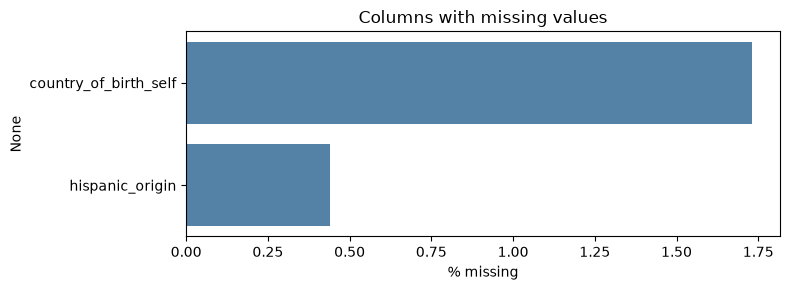

In [15]:
plt.figure(figsize=(8, 3))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="steelblue")
plt.xlabel("% missing")
plt.title("Columns with missing values")
plt.tight_layout()
plt.show()

**Notes**
- Only two columns still have missing values, and both are under 2%. Dropping the migration columns removed the biggest gaps.
- Text like Not in universe is not missing data. It means the question did not apply to that person (for example, a child has no occupation). It is a valid category.

In [16]:
income_counts = df["income_label"].value_counts()
pd.DataFrame({"count": income_counts, "percent": (income_counts / len(df) * 100).round(2)})

,count,percent
income_label,,
-50000,183912,93.69
50000+,12382,6.31


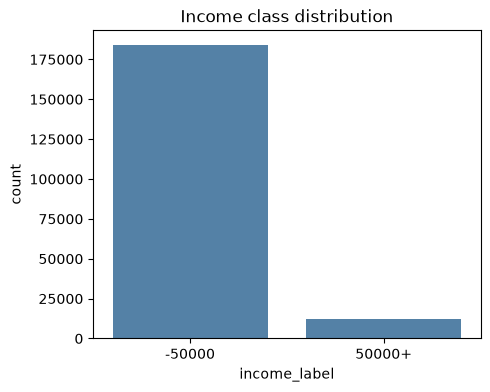

In [17]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="income_label", color="steelblue")
plt.title("Income class distribution")
plt.show()

**Notes:** the data is heavily imbalanced: only about 6% earn 50K or more. If we later build a classifier, accuracy alone would be misleading.

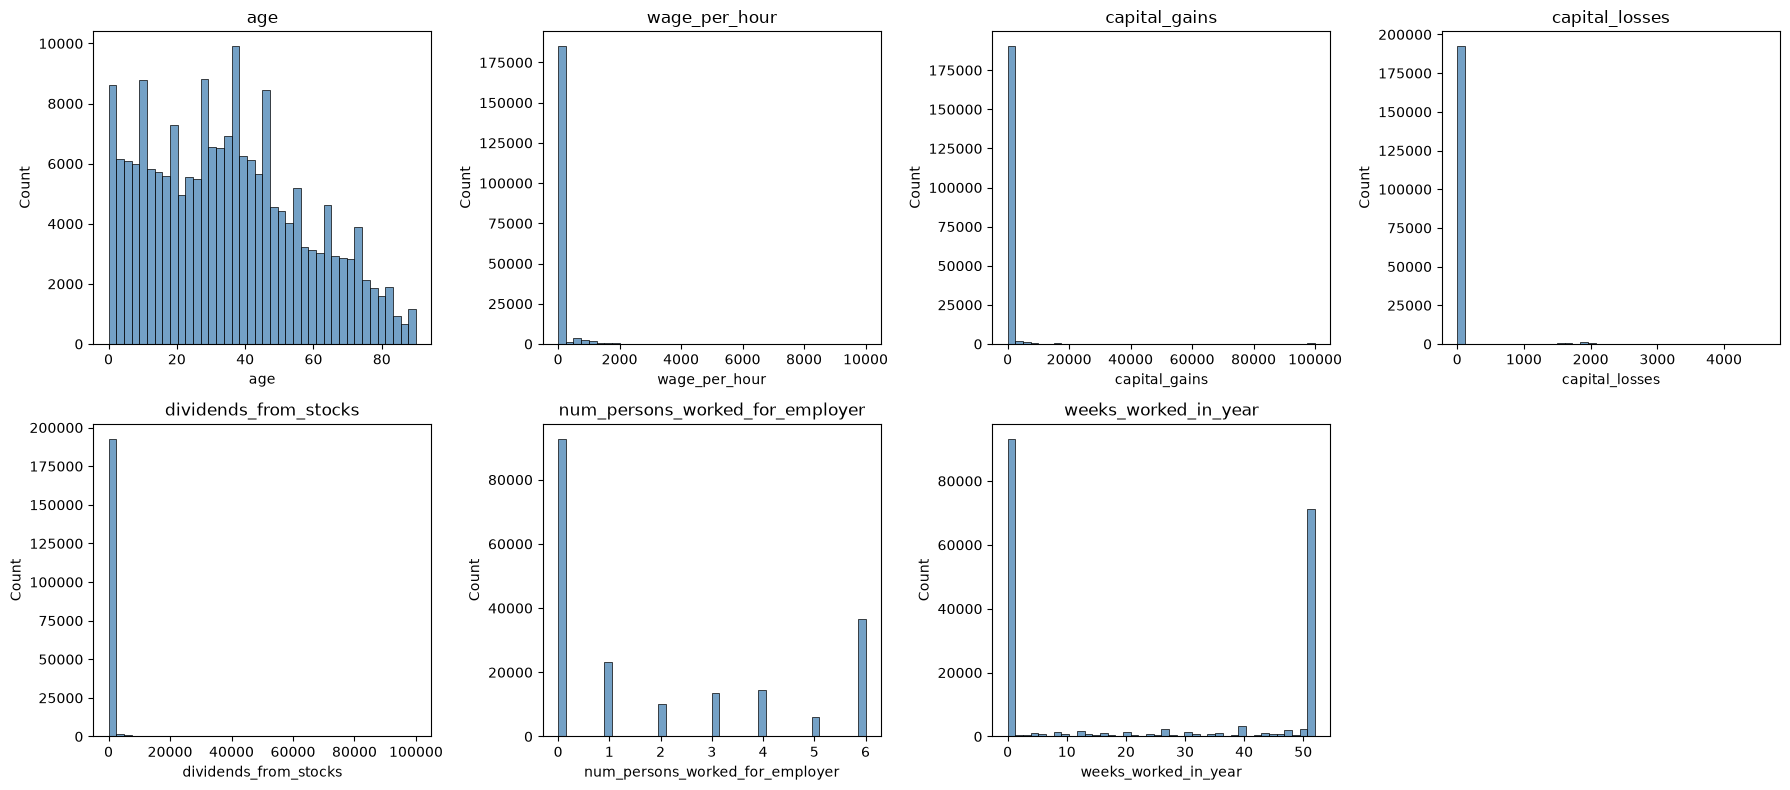

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), true_numeric):
    sns.histplot(df[col], bins=40, ax=ax, color="steelblue")
    ax.set_title(col)
axes.ravel()[-1].axis("off")   # 7 plots on a 2x4 grid, hide the empty one
plt.tight_layout()
plt.show()

In [19]:
# Many money columns are mostly zero. Checking how much:
zero_share = (df[true_numeric] == 0).mean().mul(100).round(1)
skewness = df[true_numeric].skew().round(2)
pd.DataFrame({"% zeros": zero_share, "skewness": skewness})

,% zeros,skewness
age,1.3,0.36
wage_per_hour,94.2,8.86
capital_gains,96.2,18.84
capital_losses,98.0,7.57
dividends_from_stocks,89.2,27.57
num_persons_worked_for_employer,47.3,0.73
weeks_worked_in_year,47.3,0.18


**Notes**
- wage_per_hour, capital_gains, capital_losses and dividends_from_stocks are zero for the vast majority of people (89–98%) and have a few extreme values. They are strongly right-skewed.
- age is spread across all ages, with fewer older people.
- weeks_worked_in_year has two big spikes: 0 (did not work) and 52 (worked all year).

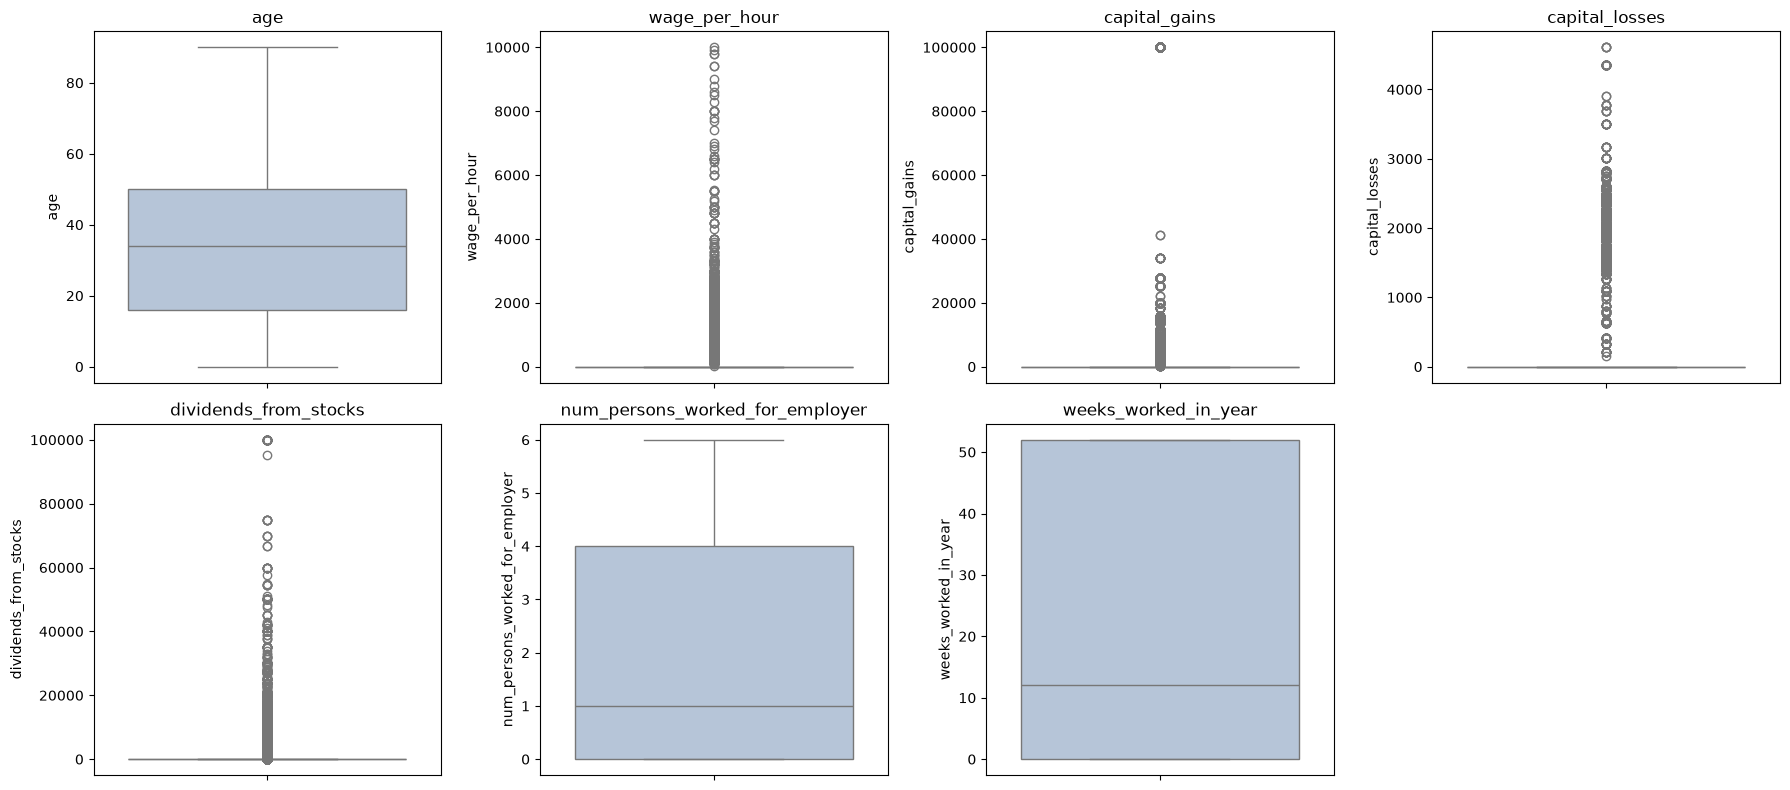

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), true_numeric):
    sns.boxplot(y=df[col], ax=ax, color="lightsteelblue")
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

**Notes:** the money columns show extreme outliers (up to 99,999). These are real values from the survey (99,999 is often a top-code cap), so we keep them but remember they will pull on any method that uses distances or variance, including PCA.

In [21]:
# How many different values does each categorical column have?
df[categorical_cols].nunique().sort_values(ascending=False)

country_of_birth_self                        42
major_industry_code                          24
education                                    17
major_occupation_code                        15
class_of_worker                               9
hispanic_origin                               9
full_or_part_time_employment_stat             8
detailed_household_summary_in_household       8
marital_stat                                  7
tax_filer_stat                                6
region_of_previous_residence                  6
reason_for_unemployment                       6
citizenship                                   5
race                                          5
family_members_under_18                       5
enroll_in_edu_inst_last_wk                    3
member_of_labor_union                         3
fill_inc_questionnaire_for_veterans_admin     3
live_in_this_house_1_year_ago                 3
sex                                           2
income_label                            

In [ ]:
df['education'].unique()

<ArrowStringArray>
[                  'High school graduate',
             'Some college but no degree',
                             '10th grade',
                               'Children',
             'Bachelors degree(BA AB BS)',
 'Masters degree(MA MS MEng MEd MSW MBA)',
                    'Less than 1st grade',
     'Associates degree-academic program',
                      '7th and 8th grade',
                  '12th grade no diploma',
    'Associates degree-occup /vocational',
 'Prof school degree (MD DDS DVM LLB JD)',
                       '5th or 6th grade',
                             '11th grade',
              'Doctorate degree(PhD EdD)',
                              '9th grade',
               '1st 2nd 3rd or 4th grade']
Length: 17, dtype: str

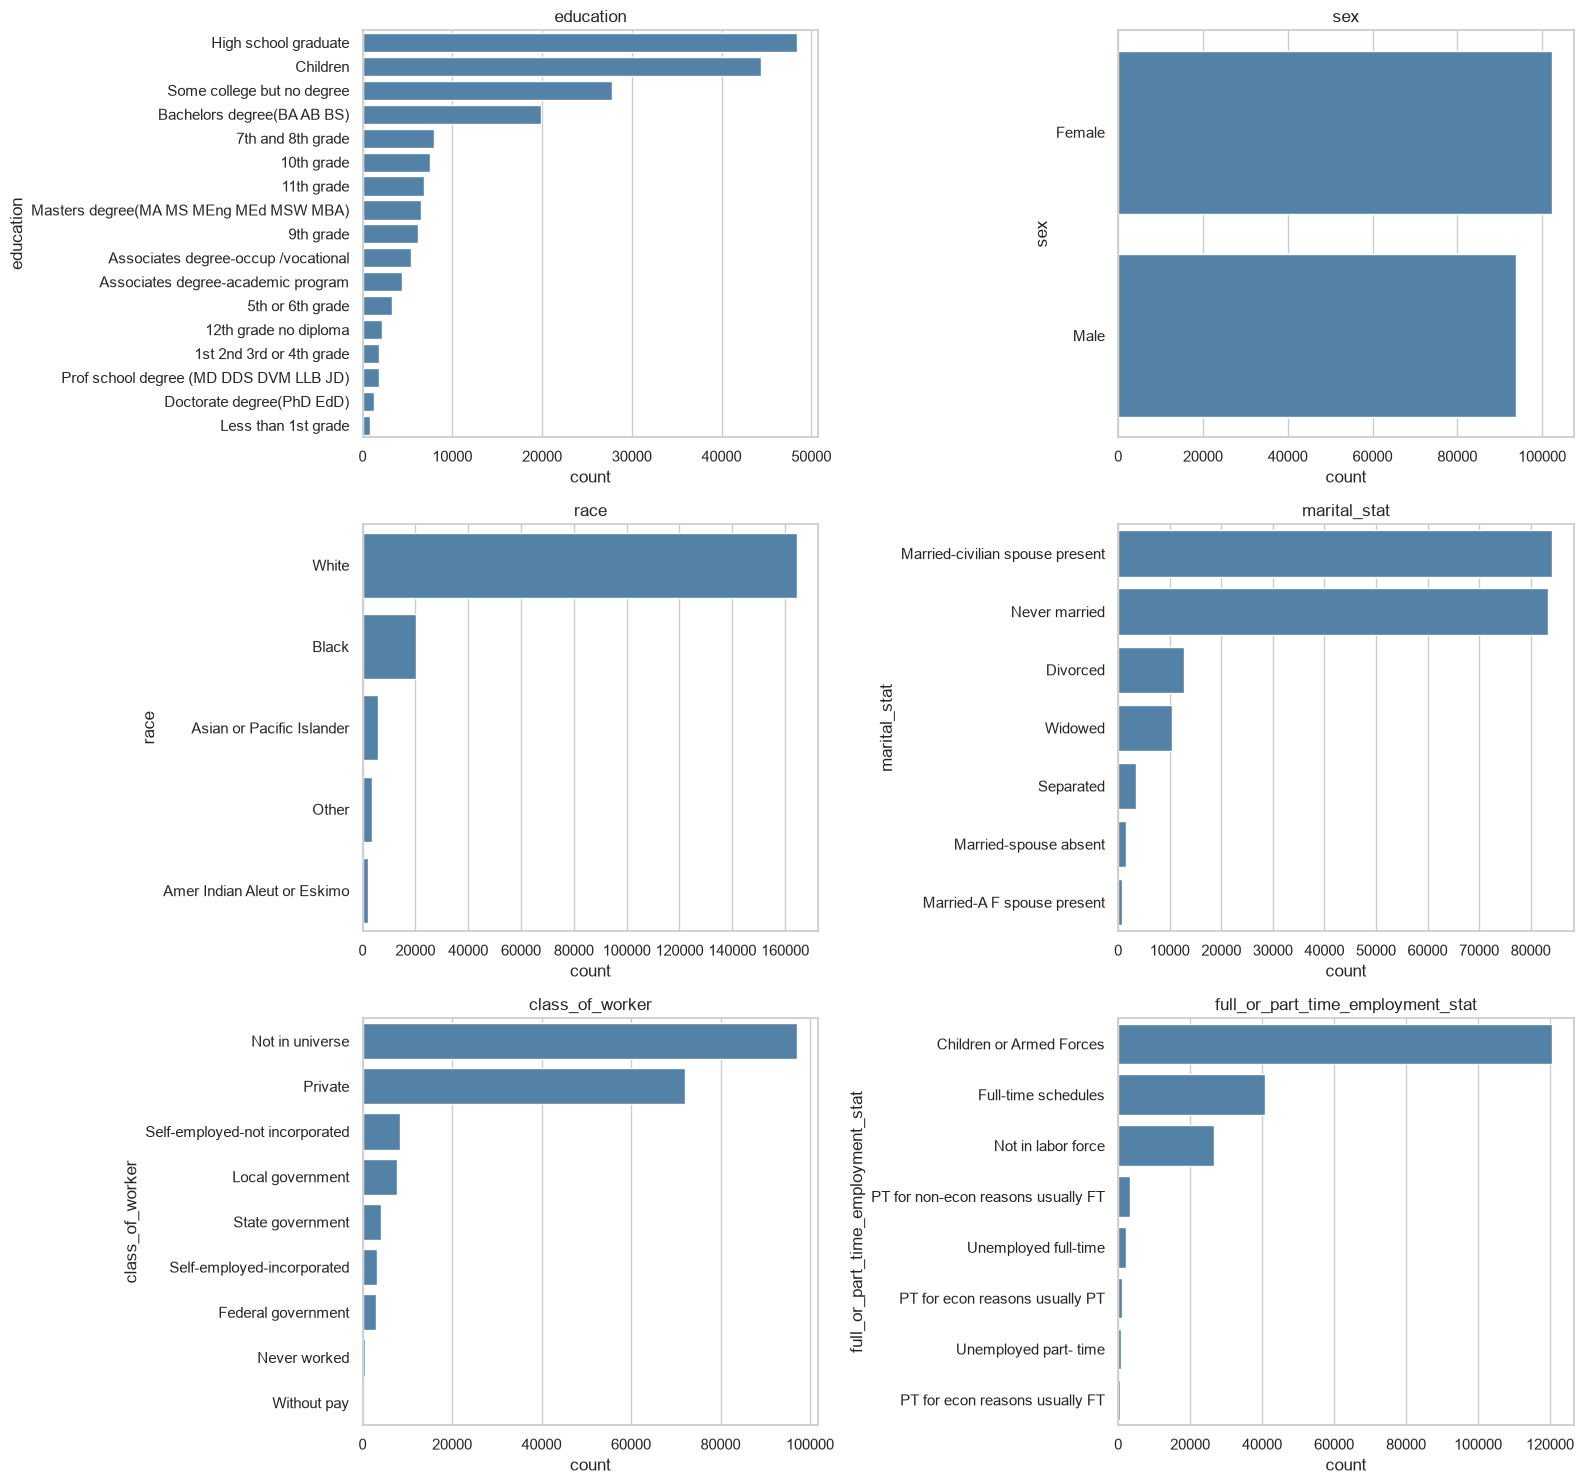

In [704]:
key_cats = ["education", "sex", "race", "marital_stat", "class_of_worker", "full_or_part_time_employment_stat"]

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
for ax, col in zip(axes.ravel(), key_cats):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, color="steelblue", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Features vs the target

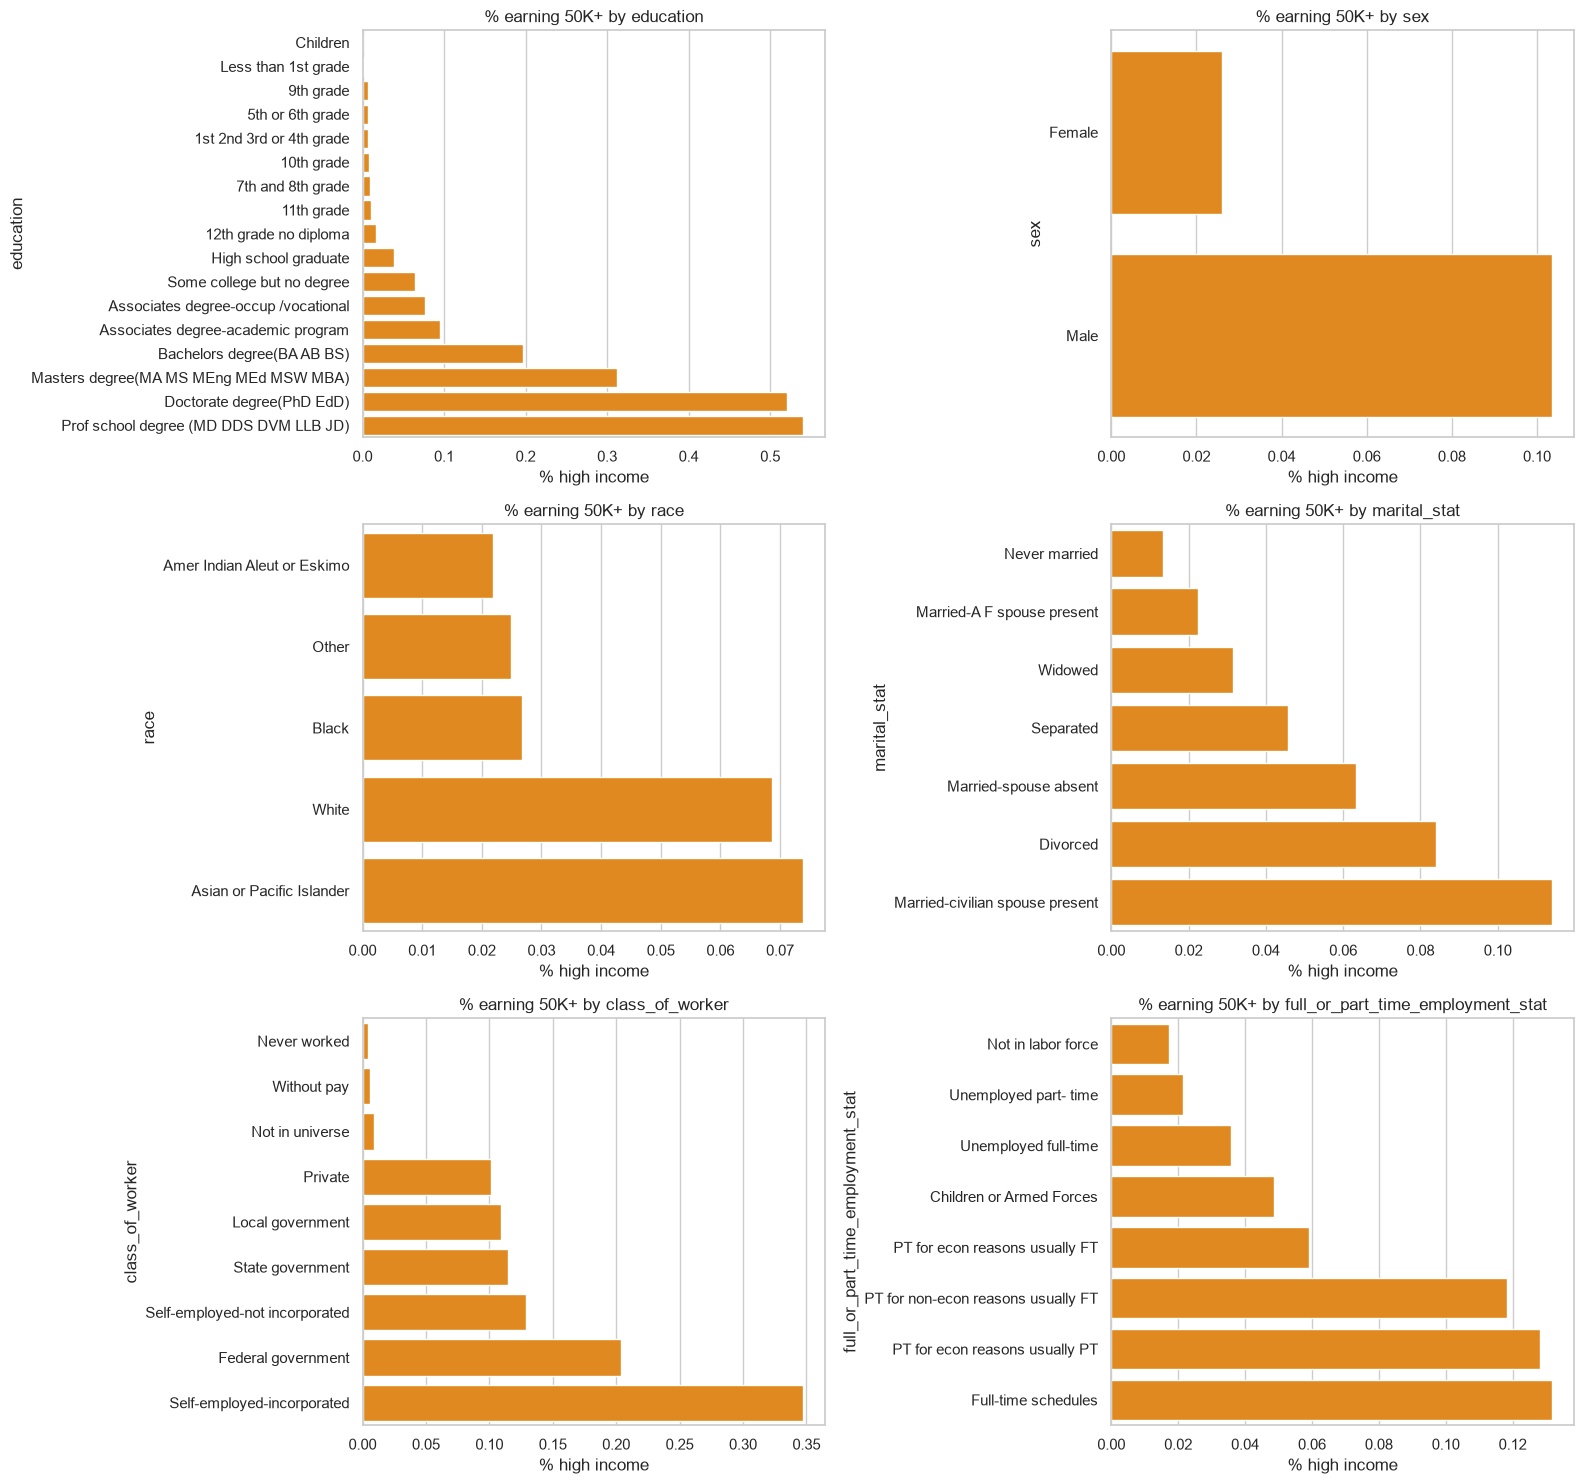

In [705]:
# Percentage of each group that earns 50K+
df["high_income"] = (df["income_label"] == "50000+").astype(int)

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
for ax, col in zip(axes.ravel(), key_cats):
    rate = df.groupby(col)["high_income"].mean().sort_values()
    sns.barplot(x=rate.values, y=rate.index, color="darkorange", ax=ax)
    ax.set_title("% earning 50K+ by " + col)
    ax.set_xlabel("% high income")
plt.tight_layout()
plt.show()

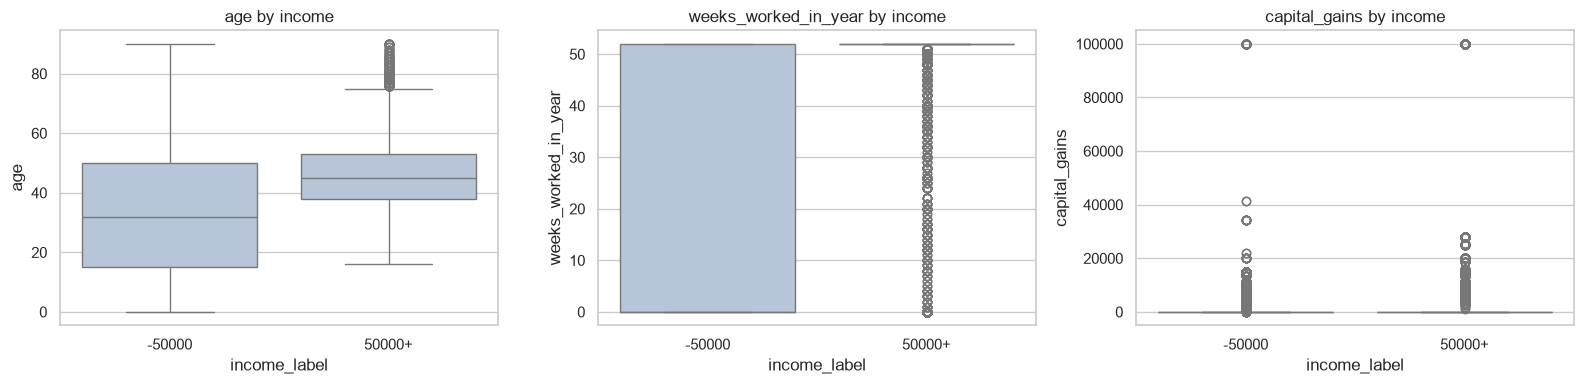

In [706]:
# Numeric features split by income class
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["age", "weeks_worked_in_year", "capital_gains"]):
    sns.boxplot(data=df, x="income_label", y=col, ax=ax, color="lightsteelblue")
    ax.set_title(col + " by income")
plt.tight_layout()
plt.show()

In [707]:
df.groupby("income_label")[true_numeric].mean().round(1)

,age,wage_per_hour,capital_gains,capital_losses,dividends_from_stocks,num_persons_worked_for_employer,weeks_worked_in_year
income_label,,,,,,,
-50000,34.2,54.6,146.4,27.5,109.6,1.9,21.9
50000+,46.3,81.6,4830.9,193.1,1553.4,4.0,48.1


**Notes**
- Higher education has a much higher share of 50K+ earners: about 20% for Bachelors, 31% for Masters and over 50% for Doctorate and Professional degrees.
- Men (about 10% earn 50K+) are far ahead of women (about 3%). Married people living with a spouse (about 11%) and full-time workers (about 13%) also have higher rates.
- High earners are older (about 46 vs 34 on average), worked far more weeks (about 48 vs 22) and have much larger capital gains and dividends on average.

## Correlation between numeric features

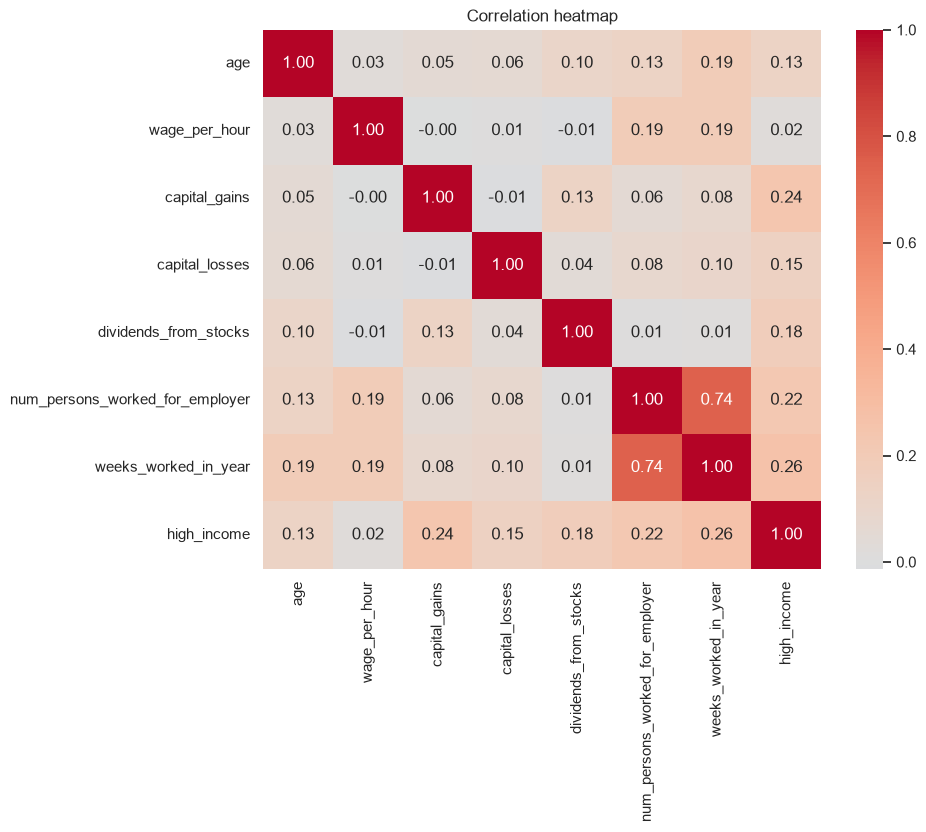

In [708]:
corr = df[true_numeric + ["high_income"]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()

**Notes:** most numeric features are only weakly correlated with each other. The one strong pair is weeks_worked_in_year and num_persons_worked_for_employer (about 0.74), because both are zero for people who did not work. Against income, the strongest links are weeks_worked_in_year (about 0.26), capital_gains (0.24) and num_persons_worked_for_employer (0.22), followed by dividends_from_stocks (0.18) and age (0.13). Because most features are weakly correlated, PCA cannot squeeze them into just one or two components.

## EDA summary
- **Size after cleaning:** about 196K rows and 30 columns (7 true numeric, the rest categorical or codes).
- **Target:** imbalanced (about 94% below 50K).
- **Missing:** only hispanic_origin (0.4%) and country_of_birth_self (1.7%) after dropping the migration columns.
- **Skew:** money columns are mostly zeros with extreme outliers.
- **Signals:** education, age, weeks worked, marital status, sex, and capital gains are all related to income.
- **Possible further drops:** fill_inc_questionnaire_for_veterans_admin (99% 'Not in universe') and reason_for_unemployment (96%) hold almost no information.

# Part 2: PCA (Principal Component Analysis)

**Idea:** PCA builds new features (*components*) that are combinations of the original ones. The first component captures the most variance, the second the next most, and so on. It only works on numeric data, so we use our 7 true numeric features.

**Important steps**
1. Split into 80% train and 20% test (stratify keeps the share of high earners equal in both).
2. Scale the features. PCA is driven by variance, so a column like capital_gains (up to 99,999) would otherwise dominate age (up to 90).
3. Fit the scaler and PCA on train only, then apply them to test.

In [709]:
X = df[true_numeric]
y = df["income_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "% high income": [(y_train == "50000+").mean() * 100, (y_test == "50000+").mean() * 100],
}, index=["train", "test"]).round(2)

,rows,% high income
train,157035,6.31
test,39259,6.31


In [710]:
X.isna().sum().sum()   # missing values in the numeric features (should be 0)

np.int64(0)

In [711]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn mean/std from train, then apply
X_test_scaled = scaler.transform(X_test)         # reuse the same mean/std on test

# On train every column should have mean ~0 and std ~1
pd.DataFrame({
    "mean": X_train_scaled.mean(axis=0).round(3),
    "std": X_train_scaled.std(axis=0).round(3),
}, index=true_numeric)

,mean,std
age,0.0,1.0
wage_per_hour,0.0,1.0
capital_gains,0.0,1.0
capital_losses,-0.0,1.0
dividends_from_stocks,0.0,1.0
num_persons_worked_for_employer,0.0,1.0
weeks_worked_in_year,-0.0,1.0


## Fit PCA with all components (train)

In [712]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

var_table = pd.DataFrame({
    "component": ["PC" + str(i + 1) for i in range(len(true_numeric))],
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative": np.cumsum(pca_full.explained_variance_ratio_),
}).round(4)
var_table

,component,explained_variance_ratio,cumulative
0,PC1,0.2749,0.2749
1,PC2,0.1670,0.4420
2,PC3,0.1447,0.5866
3,PC4,0.1302,0.7168
4,PC5,0.1299,0.8467
5,PC6,0.1171,0.9639
6,PC7,0.0361,1.0000


## Scree plot and cumulative variance

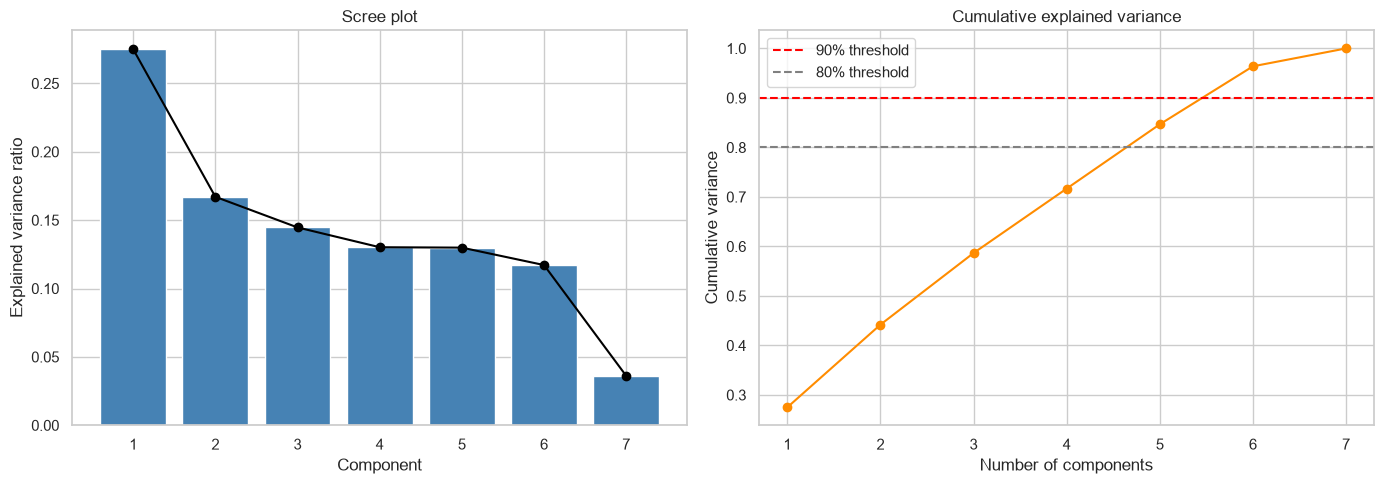

In [713]:
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
x = np.arange(1, len(evr) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x, evr, color="steelblue")
axes[0].plot(x, evr, "o-", color="black")
axes[0].set_title("Scree plot")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained variance ratio")

axes[1].plot(x, cum, "o-", color="darkorange")
axes[1].axhline(0.90, color="red", linestyle="--", label="90% threshold")
axes[1].axhline(0.80, color="gray", linestyle="--", label="80% threshold")
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance")
axes[1].legend()

plt.tight_layout()
plt.show()

In [714]:
pd.Series({
    "components for 80% variance": int(np.argmax(cum >= 0.80) + 1),
    "components for 90% variance": int(np.argmax(cum >= 0.90) + 1),
})

components for 80% variance    5
components for 90% variance    6
dtype: int64

- The scree plot shows how much each component adds. Look for the "elbow" where the bars flatten out.
- The cumulative plot shows how many components you need to keep a target share (commonly 80–90%) of the information.

## Choose the number of components and transform

In [715]:
# Keep enough components to explain at least 90% of variance
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)   # fit on train
X_test_pca = pca.transform(X_test_scaled)         # only transform test

pd.Series({
    "original features": X_train_scaled.shape[1],
    "components kept": pca.n_components_,
    "variance kept": round(pca.explained_variance_ratio_.sum(), 4),
})

original features    7.0000
components kept      6.0000
variance kept        0.9639
dtype: float64

In [716]:
pd.DataFrame({"train": X_train_pca.shape, "test": X_test_pca.shape}, index=["rows", "components"])

,train,test
rows,157035,39259
components,6,6


## 2D view of the data (PC1 vs PC2)

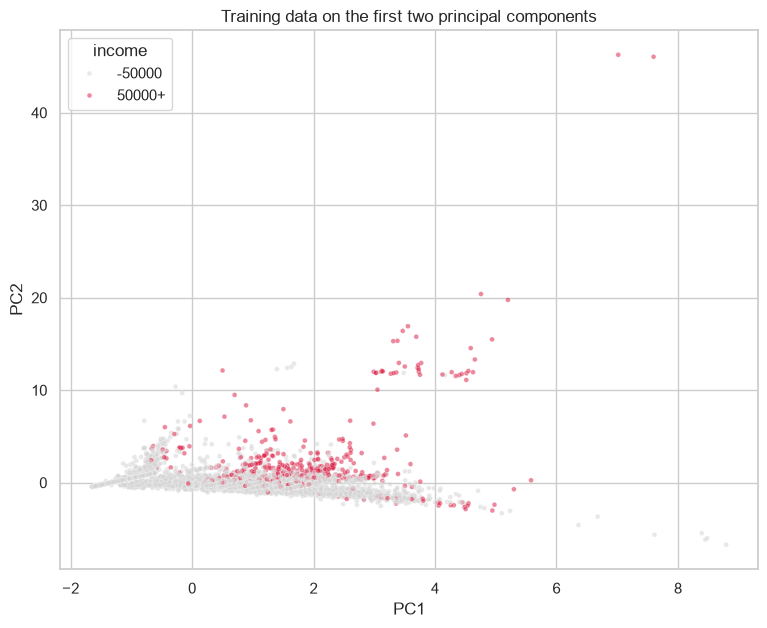

In [717]:
# Plot a random sample of 20,000 training points so the picture stays readable and fast
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X_train_pca), size=20000, replace=False)

plot_df = pd.DataFrame({
    "PC1": X_train_pca[idx, 0],
    "PC2": X_train_pca[idx, 1],
    "income": y_train.iloc[idx].values,
})

plt.figure(figsize=(9, 7))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="income",
                palette={"-50000": "lightgray", "50000+": "crimson"},
                alpha=0.5, s=12)
plt.title("Training data on the first two principal components")
plt.show()

**Notes:** high earners (red) sit mostly at higher PC1 values (people who worked many weeks) and are more spread out along PC2 (large capital gains or dividends). The gray majority is packed near the centre, so there is heavy overlap: PCA on these numeric features alone does not separate the classes cleanly. A few extreme points stretch the axes, which comes from the outliers we saw in the EDA.

## What does each component mean? (loadings)

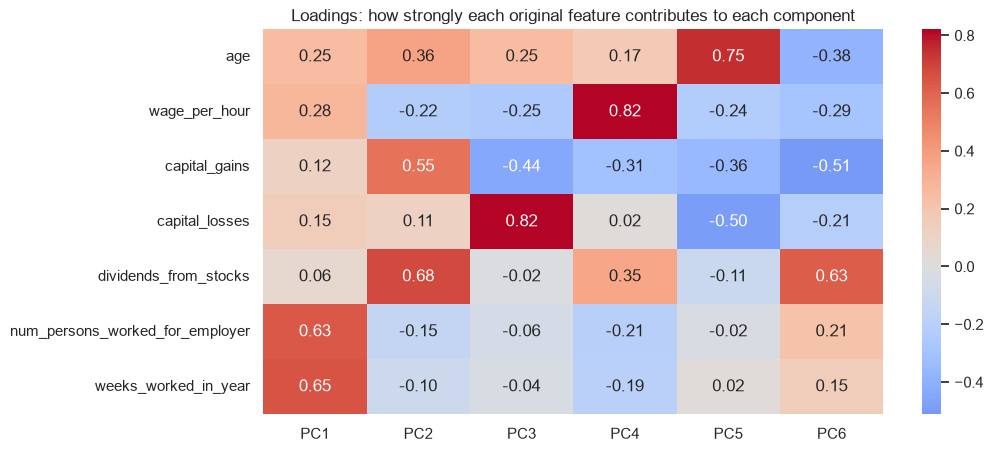

In [718]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=true_numeric,
    columns=["PC" + str(i + 1) for i in range(len(true_numeric))],
)

plt.figure(figsize=(10, 5))
sns.heatmap(loadings.iloc[:, :pca.n_components_], annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Loadings: how strongly each original feature contributes to each component")
plt.show()

### From above heatmap we can conclude :

- which component is most co-related to different Principal components (see below table)

In [719]:
# The 3 biggest contributors (by absolute value) for each kept component
top_features = pd.DataFrame({
    col: loadings[col].abs().sort_values(ascending=False).head(3).index.tolist()
    for col in loadings.columns[:pca.n_components_]
}, index=["1st", "2nd", "3rd"])
top_features

,PC1,PC2,PC3,PC4,PC5,PC6
1st,weeks_worked_in_year,dividends_from_stocks,capital_losses,wage_per_hour,age,dividends_from_stocks
2nd,num_persons_worked_for_employer,capital_gains,capital_gains,dividends_from_stocks,capital_losses,capital_gains
3rd,wage_per_hour,age,wage_per_hour,capital_gains,capital_gains,age


## Checking if the test data behave like the training data?

In [720]:
# Reconstruction error: project back to the original (scaled) space and compare
def recon_error(X_scaled, pca_model):
    X_back = pca_model.inverse_transform(pca_model.transform(X_scaled))
    return np.mean((X_scaled - X_back) ** 2)

pd.Series({
    "reconstruction error (train)": recon_error(X_train_scaled, pca),
    "reconstruction error (test)": recon_error(X_test_scaled, pca),
}).round(4)

reconstruction error (train)    0.0361
reconstruction error (test)     0.0358
dtype: float64

If the train and test errors are similar, the components learned from the training set generalise well to unseen data.

## Final takeaways
- After removing 3,229 exact duplicate rows and 12 columns, the dataset has 196,294 rows and 30 columns. The 80/20 split gives 157,035 train rows and 39,259 test rows, with the same 6.3% share of high earners in both.
- PCA needs 5 of the 7 components to reach 80% of the variance and 6 to reach 90% (6 components keep about 96%). The reduction is modest because most features are only weakly correlated. Only `weeks_worked_in_year` and `num_persons_worked_for_employer` overlap strongly.
- **PC1** is driven mainly by weeks worked, number of employers and hourly wage. **PC2** is driven mainly by dividends and capital gains.
- The reconstruction error is almost the same on train (0.0361) and test (0.0358), so the components learned on train generalise well to unseen data.
- The zero-heavy, skewed money columns strongly influence the components even after scaling. A useful next step would be applying `np.log1p()` to `wage_per_hour`, `capital_gains`, `capital_losses` and `dividends_from_stocks` before scaling, then comparing the results.
- PCA used only the 7 numeric columns. The categorical columns (education, marital status and so on) carry much of the signal about income, so a next step would be one-hot encoding them.

## Part 3: K-Means clustering and DBSCAN

### K-Means Clustering

- K-Means is used for unsupervised learning, meaning it finds hidden patterns or natural groupings in data that does not have predefined labels.
- A cluster is a group of data points that are similar to each other.
- In this we use Elbon method to find the value of 'K'.
- How Geometric Intuition Works:
    * Pick $K$: Choose how many clusters ($K$) you want to create (e.g., $K=3$).
    * Place Centroids: Place $K$ starting center points (called centroids) randomly in your data space.
    * Assign Points: Look at every data point and assign it to whichever centroid is closest.
    * Update Centroids: Move each centroid to the exact center (average position) of all points currently assigned to its cluster.
    * Repeat: Keep repeating steps 3 and 4 until the centroids stop moving (convergence).

### DBSCAN(Density based spatial clustering of algorithm with Noises)

- Unlike centroid-based algorithms, DBSCAN forms clusters by identifying dense regions* (areas with a high concentration of data points   separated by sparse regions (areas with few or no points).
- Because it relies purely on local point density, cluster shape does not matter.
- DBSCAN relies on two fundamental hyperparameters to measure local density:
    * Epsilon / eps: The radius of the circular neighborhood drawn around any given data point
    * MinPoints (min_samples): The minimum number of data points required within a point's epsilon-neighborhood for that region to be   considered "dense".
- Based on epsilon and MinPoints, DBSCAN categorizes every data point into one of three types:
    * Core Point: A data point that has at least MinPoints or more points inside its epsilon-neighborhood (including itself).
    * Border Point: A data point that has fewer than MinPoints inside its epsilon-neighborhood, but contains at least one Core Point within its neighborhood.
    * Noise Point (Outlier): A data point that is neither a Core Point nor a Border Point.
- The 4-Step DBSCAN Algorithm Workflow:
    * Step 0 (Initialization): Define values for hyperparameter epsilon and MinPoints.
    * Step 1 (Point Classification): Calculate neighborhood densities for all data points and label each point as either a Core Point, Border Point, or Noise Point.
    * Step 2 (Clustering Core Points):Select an unclustered Core Point and assign it to a new cluster2122.Recursively add all unclustered points that are density-connected to it into the same cluster2223.Repeat until all Core Points are assigned to clusters.
    * Step 3 (Assigning Border Points): Assign each unclustered Border Point to the cluster of its nearest Core Point25.
    * Step 4 (Handling Noise): Leave Noise Points unassigned (or mark them as outliers).
- Advantages
    * Robust to Outliers: Built-in capability to detect and isolate noise points (-1) automatically.
    * No Pre-specified K: Does not require you to guess or specify the number of clusters beforehand.
    * Arbitrary Cluster Shapes: Easily clusters complex, non-spherical geometric structures like concentric circles.
    * Minimal Tuning: Requires tuning only two hyperparameters (epsilon and min_samples).
- Limitations
    * Sensitivity to Hyperparameters: Small changes to epsilon or min_samples can lead to vastly different clustering results.
    * Varying Densities: Struggles when clusters in the dataset have significantly different densities, as a single global epsilon cannot fit both dense and sparse clusters effectively.
    * No predict() Function: DBSCAN cannot make predictions on new, unseen data points without re-clustering the entire dataset from scratch.

# Part 4: Preparing the full feature set for modeling

PCA only used the 7 numeric columns. To predict income as well as possible, our models should also use the categorical columns (education, marital status, occupation, and so on), since the EDA showed these carry a lot of signal.

**What still needs to be done before training:**
1. Turn the target into 0/1
2. Fill the small amount of remaining missing values in the categorical columns
3. Split 80/20 (same split style as before, done separately here since we now use all columns, not just the 7 numeric ones)
4. Scale the numeric columns and one-hot encode the categorical columns

In [721]:
model_df = df.drop(columns=["high_income"])   # drop the helper column made during EDA

y_all = (model_df["income_label"] == "50000+").astype(int)
X_all = model_df.drop(columns=["income_label"])

numeric_features = true_numeric
categorical_features = [c for c in X_all.columns if c not in numeric_features]

pd.Series({
    "numeric features": len(numeric_features),
    "categorical features": len(categorical_features),
})

numeric features         7
categorical features    22
dtype: int64

In [722]:
# One-hot encoding cannot handle NaN, so we fill missing categories with a real category name
X_all[categorical_features] = X_all[categorical_features].fillna("Missing")
X_all.isna().sum().sum()

np.int64(0)

In [723]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_all, y_all, test_size=0.20, random_state=RANDOM_STATE, stratify=y_all
)

pd.DataFrame({
    "rows": [len(X_train_full), len(X_test_full)],
    "% high income": [y_train_full.mean() * 100, y_test_full.mean() * 100],
}, index=["train", "test"]).round(2)

,rows,% high income
train,157035,6.31
test,39259,6.31


## Scale numeric columns, one-hot encode categorical columns

ColumnTransformer lets us apply a different step to different columns in one object, and fit it on train only.

In [724]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

X_train_model = preprocessor.fit_transform(X_train_full)   # learn from train, then apply
X_test_model = preprocessor.transform(X_test_full)         # reuse what was learned on train

pd.Series({
    "original columns": X_train_full.shape[1],
    "columns after encoding": X_train_model.shape[1],
})

original columns           29
columns after encoding    201
dtype: int64

In [725]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

X_train_model = preprocessor.fit_transform(X_train_full)   # learn from train, then apply
X_test_model = preprocessor.transform(X_test_full)         # reuse what was learned on train

pd.Series({
    "original columns": X_train_full.shape[1],
    "columns after encoding": X_train_model.shape[1],
})

original columns           29
columns after encoding    201
dtype: int64

**Notes:** one-hot encoding turns each category into its own 0/1 column and (handle_unknown="ignore") means that if the test set ever contained a category never seen in training, it would be encoded as all zeros instead of causing an error.

## Class imbalance
Only about 6% of people earn 50K+. Left as is, a model can reach high accuracy just by predicting "below 50K" every time, while never correctly finding a high earner. We handle this per model below (class_weight for Random Forest, scale_pos_weight for XGBoost) and judge every model with more than accuracy: precision, recall, F1-score, and ROC-AUC for the 50K+ class.

In [726]:
class_ratio = (y_train_full == 0).sum() / (y_train_full == 1).sum()
class_ratio.round(2)

np.float64(14.85)

## Hyperparameter tuning and model training

Instead of picking settings like the number of trees or the tree depth by guessing, we search for good ones automatically:
- GridSearchCV tries every combination in a grid, which guarantees finding the best combination in that grid, but gets slow very fast as more settings are added.
- RandomizedSearchCV instead tries a fixed number of random combinations. It usually finds settings almost as good, in a fraction of the time.

With 157K training rows, even RandomizedSearchCV with cross-validation can be slow, so we tune on a smaller, stratified sample of the training data, then train the final model with the best settings found on the full training set. This is a common, practical shortcut: search fast on a sample, then commit to the full data once.

## Build a tuning sample

In [727]:
# A 20,000-row stratified sample keeps the search fast while still being
# large enough to compare settings reliably.
X_tune, _, y_tune, _ = train_test_split(
    X_train_model, y_train_full, train_size=20000, random_state=RANDOM_STATE, stratify=y_train_full
)
pd.Series({"tuning rows": X_tune.shape[0], "% high income": (y_tune.mean() * 100).round(2)})

tuning rows      20000.00
% high income        6.31
dtype: float64

## Model 1: Random Forest

In [728]:
rf_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 10, 12, 14, 16],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=8,          # try 8 random combinations
    cv=3,              # 3-fold cross-validation on the tuning sample
    scoring="roc_auc", # a good metric to optimise on an imbalanced target
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_search.fit(X_tune, y_tune)

pd.Series({**rf_search.best_params_, "best_cv_roc_auc": round(rf_search.best_score_, 4)})

n_estimators          200
min_samples_leaf        2
max_features         sqrt
max_depth              12
best_cv_roc_auc     0.933
dtype: object

In [729]:
# Train the final Random Forest with the best settings, on the FULL training set
rf_model = RandomForestClassifier(
    **rf_search.best_params_,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train_model, y_train_full)
rf_pred = rf_model.predict(X_test_model)
rf_proba = rf_model.predict_proba(X_test_model)[:, 1]
"Random Forest trained"

'Random Forest trained'

## Model 2: AdaBoost

In [730]:
ada_param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.3, 0.5, 1.0, 1.5],
}

ada_search = RandomizedSearchCV(
    AdaBoostClassifier(random_state=RANDOM_STATE),
    param_distributions=ada_param_dist,
    n_iter=6,
    cv=3,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
ada_search.fit(X_tune, y_tune)

pd.Series({**ada_search.best_params_, "best_cv_roc_auc": round(ada_search.best_score_, 4)})

n_estimators       200.0000
learning_rate        1.5000
best_cv_roc_auc      0.9393
dtype: float64

In [731]:
ada_model = AdaBoostClassifier(
    **ada_search.best_params_,
    random_state=RANDOM_STATE,
)
ada_model.fit(X_train_model, y_train_full)
ada_pred = ada_model.predict(X_test_model)
ada_proba = ada_model.predict_proba(X_test_model)[:, 1]
"AdaBoost trained"

'AdaBoost trained'

**Notes:** AdaBoost builds many weak learners (shallow trees, by default depth 1) one after another, each one focusing more on the examples the previous ones got wrong. Unlike Random Forest, scikit-learn's AdaBoostClassifier has no class_weight option, so it does not get any direct help with the imbalance the way our other models do.

## Model 3: Gradient Boosting

In [732]:
gb_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.9, 1.0],
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=gb_param_dist,
    n_iter=8,
    cv=3,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
gb_search.fit(X_tune, y_tune)

pd.Series({**gb_search.best_params_, "best_cv_roc_auc": round(gb_search.best_score_, 4)})

subsample            0.7000
n_estimators       200.0000
max_depth            2.0000
learning_rate        0.1000
best_cv_roc_auc      0.9434
dtype: float64

In [733]:
gb_model = GradientBoostingClassifier(
    **gb_search.best_params_,
    random_state=RANDOM_STATE,
)
gb_model.fit(X_train_model, y_train_full)
gb_pred = gb_model.predict(X_test_model)
gb_proba = gb_model.predict_proba(X_test_model)[:, 1]
"Gradient Boosting trained"

'Gradient Boosting trained'

**Notes:** Gradient Boosting is a close relative of XGBoost — both build trees one after another, each new tree correcting the errors of the ones before it, using the gradient of the loss function. XGBoost adds engineering on top (regularization terms, an optimized histogram-based split-finding algorithm, and built-in imbalance handling via scale_pos_weight), which is why it usually edges out plain Gradient Boosting on both speed and accuracy. Like AdaBoost, scikit-learn's GradientBoostingClassifier has no class_weight option, so it also gets no direct help with the imbalance.

## Model 4: XGBoost

In [734]:
xgb_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=class_ratio, random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss"),
    param_distributions=xgb_param_dist,
    n_iter=10,
    cv=3,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_search.fit(X_tune, y_tune)

pd.Series({**xgb_search.best_params_, "best_cv_roc_auc": round(xgb_search.best_score_, 4)})

subsample             0.7000
n_estimators        300.0000
max_depth             4.0000
learning_rate         0.0500
colsample_bytree      0.7000
best_cv_roc_auc       0.9423
dtype: float64

In [735]:
xgb_model = XGBClassifier(
    **xgb_search.best_params_,
    scale_pos_weight=class_ratio,   # tells XGBoost the 50K+ class is rare
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="logloss",
)
xgb_model.fit(X_train_model, y_train_full)
xgb_pred = xgb_model.predict(X_test_model)
xgb_proba = xgb_model.predict_proba(X_test_model)[:, 1]
"XGBoost trained"

'XGBoost trained'

## Comparing the four tuned models

In [736]:
models = {
    "Random Forest": (rf_pred, rf_proba),
    "AdaBoost": (ada_pred, ada_proba),
    "Gradient Boosting": (gb_pred, gb_proba),
    "XGBoost": (xgb_pred, xgb_proba),
}

rows = []
for name, (pred, proba) in models.items():
    report = classification_report(y_test_full, pred, output_dict=True)
    rows.append({
        "model": name,
        "accuracy": report["accuracy"],
        "precision (50K+)": report["1"]["precision"],
        "recall (50K+)": report["1"]["recall"],
        "f1 (50K+)": report["1"]["f1-score"],
        "roc_auc": roc_auc_score(y_test_full, proba),
    })

comparison = pd.DataFrame(rows).set_index("model").round(3)
comparison.sort_values("roc_auc", ascending=False)

,accuracy,precision (50K+),recall (50K+),f1 (50K+),roc_auc
model,,,,,
XGBoost,0.859,0.297,0.901,0.447,0.950
Gradient Boosting,0.953,0.735,0.405,0.522,0.945
AdaBoost,0.952,0.721,0.392,0.508,0.944
Random Forest,0.821,0.249,0.908,0.390,0.937


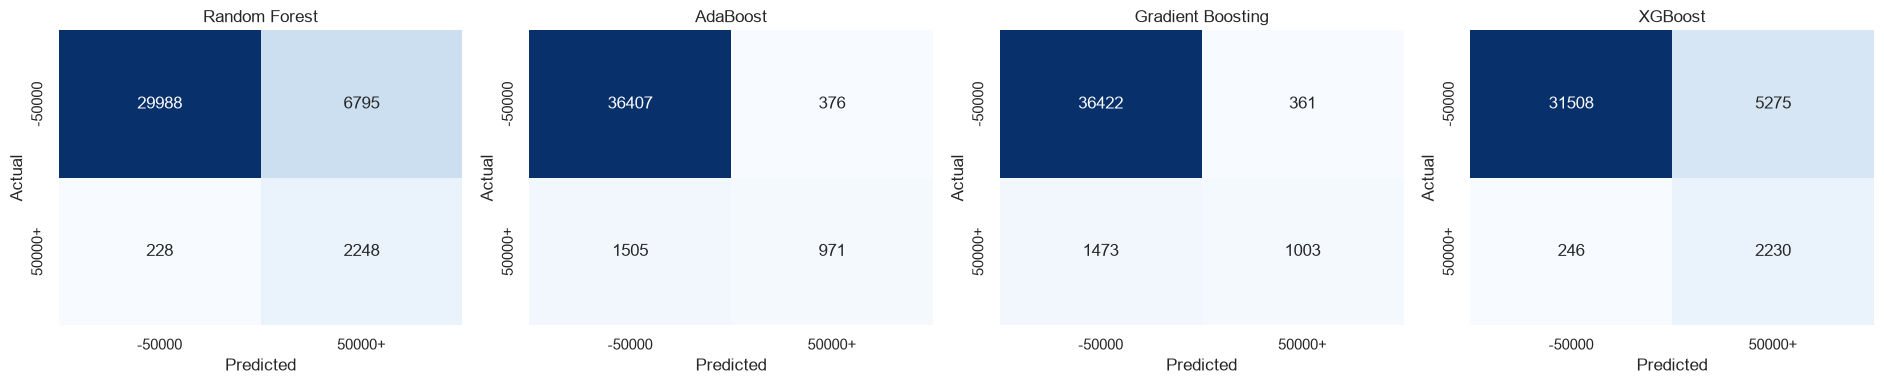

In [737]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4))
for ax, name in zip(axes, models):
    pred, _ = models[name]
    cm = confusion_matrix(y_test_full, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["-50000", "50000+"], yticklabels=["-50000", "50000+"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

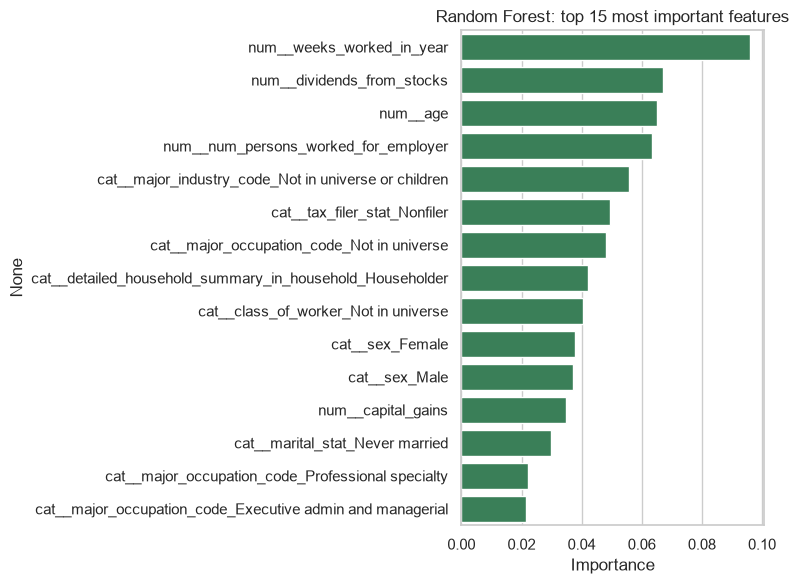

In [738]:
top_n = 15
rf_importance = pd.Series(
    rf_model.feature_importances_, index=preprocessor.get_feature_names_out()
).sort_values(ascending=False).head(top_n)

plt.figure(figsize=(8, 6))
sns.barplot(x=rf_importance.values, y=rf_importance.index, color="seagreen")
plt.title("Random Forest: top " + str(top_n) + " most important features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

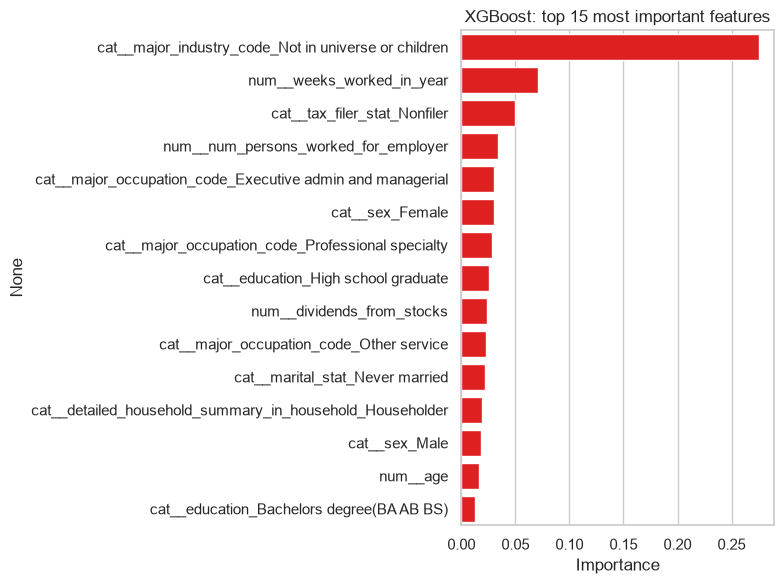

In [748]:
top_n = 15
xgb_importance = pd.Series(
    xgb_model.feature_importances_, index=preprocessor.get_feature_names_out()
).sort_values(ascending=False).head(top_n)

plt.figure(figsize=(8, 6))
sns.barplot(x=xgb_importance.values, y=xgb_importance.index, color="red")
plt.title("XGBoost: top " + str(top_n) + " most important features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Model comparison notes
- **XGBoost** gets the best balance overall: the highest ROC-AUC and F1-score for the rare 50K+ class, while training in a couple of seconds.
- **Random Forest** finds a similar share of high earners (similar recall, thanks to class_weight="balanced"), but with more false positives (lower precision) than XGBoost.
- **Gradient Boosting** lands between the two: no class_weight support like AdaBoost, but boosting (correcting past mistakes round by round) still gives it noticeably better recall than AdaBoost, closer to XGBoost's own boosting approach.
- **AdaBoost** gets the highest plain accuracy of the four, but this is a little misleading: without a class_weight option, it catches noticeably fewer of the actual high earners (lower recall) than the other three.
- **Lesson:** on an imbalanced target, accuracy alone is not a good way to pick a model. XGBoost and Random Forest, which are both told about the imbalance directly, catch far more of the rare 50K+ class than AdaBoost or plain Gradient Boosting, which are not.

In [739]:
import joblib

In [751]:
joblib.dump(xgb_model,"XGBoost.pkl")

['XGBoost.pkl']

In [753]:
xgb_ = joblib.load("XGBoost.pkl")

In [754]:
xgb_

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [755]:
xgb_.predict(X_test_model)

array([1, 0, 0, ..., 0, 0, 0], shape=(39259,))